### `I. COMPRÉHENSION DE LA PAROLE & CLASSIFICATION D’INTENTIONS`
_M2 IAFA - TAP Assistants Vocaux Interactifs 2025-202ti / Application au corpus SLURP_

#### `1.1. OBJECTIF`
En dialogue oral, la compréhension de la parole consiste à traiter le résultat de la transcription automatique (sortie texte) de chaque énoncé (signal de parole) produit par l’utilisateur.        

`L’objectif est d’en extraire l’intention (acte de dialogue sous-jacent) et, s’il y a lieu, les entités (= concepts informatifs) correspondant à des éléments pertinents pour l’application (date, horaire, personne, profession, âge, lieu…)`.

 - Le corpus SLURP regroupe des enregistrements (audio) collectés dans un contexte d’assistance vocale, ainsi que les annotations associées (fichiers json). 

 - L’utilisateur peut formuler diﬀérentes commandes (en anglais) pour gérer son agenda (calendar), ses alarmes (alarm), ses choix musicaux, le réglage de la luminorité pour des aspects IoT… 

#### _`1.2 CLASSIFICATION DES INTENTIONS`_
Le dataset SLURP est organisé en 3 parties : 
- une pour l’apprentissage (train), 
- une pour le développement (dev),
- une pour l’évaluation (test). 
Les annotations associées permettent donc de faire de la classifica1on supervisée.           
`L’objectif du TP est de tester plusieurs méthodes et plusieurs modèles de représentation (fournissant des représentations vectorielles ou embeddings pour chaque énoncé traité). Il est alors nécessaire d’analyser et de comparer les résultats obtenus.`

#### _`1.3 MÉTHODES DE CLASSIFICATION`_
_`Apprentissage supervisé`_ : Dans un premier temps nous évaluons des méthodes classiques telles que les K-plus-proches-voisins (ou K-NN), les arbres de décision (Decision Tree), l’approche Bayesienne naïve (Naïve Bayes), les réseaux de neurones (NN), … permettant de faire de la classification supervisée d’intentions.

_`Apprentissage non supervisé`_ : Dans un second temps nous pourrons également appliquer une méthode non supervisée K-moyennes (K-means) ou autre, pour comparer les résultats avec l’approche supervisée.

#### _`1.4 MODÈLES DE REPRÉSENTATION`_
_`Modèles pré-appris basés texte`_ : Nous ne traitons pas directement les fichiers audio, mais la transcription automatique déjà générée via SpeechRecognition (modèle google anglais). La transcription étant au format texte, elle doit être transformée en vecteur (ou embeddings) pour être envoyée en entrée des classifieurs. Les embeddings ont également déjà été extraits à partir de modèles pré-appris et sont fournis dans la partie du corpus mise à notre disposition. 
Deux familles de modèles de représentation basés texte, suivant une architecture Transformer, ont été utilisés :
- BERT (Bidirectional Encoder Representations from Transformers)
- Sentence-BERT, évolution de BERT centrée sur la similarité sémantique des phrases.

#### _`1.5 MÉTHODES DE RÉDUCTION DE DIMENSIONS`_ : 
Les vecteurs fournis ont des dimensions diﬀérentes suivant les modèles pré-appris utilisés : 
- BERT (768), S-BERT (364) et WavLM (768). 
Pour réduire le temps d’apprentissage et l’espace mémoire nécessaire, il faudra procéder en amont à une étape de réduction de dimensions en utilisant par exemple l’Analyse en Composante Principale (ou ACP et PCA en anglais) et en veillant à conserver au moins 80% de la variance.

#### `1.6. MÉTHODES DESCRIPTION`

#### `1.7. Pré-requis`
Dans notre TP, les features (les embeddings BERT/SBERT des phrases) ne sont pas indépendants entre eux au sens probabiliste; au contraire, ils sont fortement corrélés, car appris conjointement par le réseau.

##### `1.7.1 Indépendance et modèles utilisés`
 - Naïve Bayes suppose l’indépendance conditionnelle des features sachant la classe, ce qui est clairement violé avec des embeddings denses où chaque dimension dépend des autres.

 - Malgré cette violation, Naïve Bayes peut parfois rester « assez bon » en pratique, mais on ne peut pas interpréter ses probabilités comme si l’hypothèse d’indépendance était vraie.

 - Pour k‑NN, Decision Tree, Neural Network et k‑means, on ne fait pas d’hypothèse sur l'indépendance des features; ces méthodes acceptent sans problème des features corrélés.

`Pour notre problème d’intentions sur embeddings, nous dirons donc` : que les features ne sont pas indépendants, et seul Naïve Bayes est en « décalage » avec sa supposition théorique, ce qui peut expliquer des performances ou une interprétabilité différentes des autres modèles.

#### `1.8. Distribution des données`

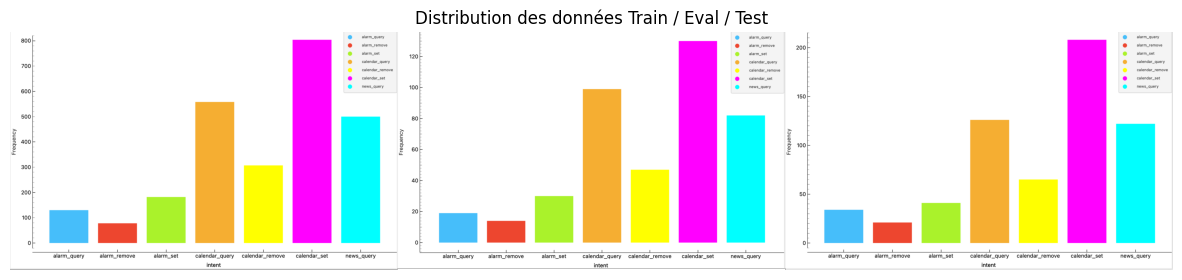

In [30]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP3_SLRP_2026/images/distribution.png")
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.axis('off')
plt.title("Distribution des données Train / Eval / Test")
plt.show()

`Ce que montrent les chiffres`
- Avec 7 intentions avec entre ~70 et ~800 exemples chacune; 
- C’est déséquilibré mais aucune.
- Ces 7 intentions représentent quelques milliers d’exemples.
- Les différentes distributions de classe sont équivalentes.
- c'est jouable avec un MLP peu profond.
`Conséquences pour le modèle neural network`
- Avec un réseau modeste, le rapport paramètres / données permet de controler l’overfitting.
- Ce déséquilibre demandera pondération des classes ou métriques macro, sans augmentation  de données.  

Au vu du nombre total d’exemples disponibles et de la fréquence de chacune des 7 intentions retenues, l’utilisation d’un réseau de neurones de taille modérée apparaît justifiée et compatible avec le volume de données du corpus.

#### `1.9. Configuration de l'outil Orange`

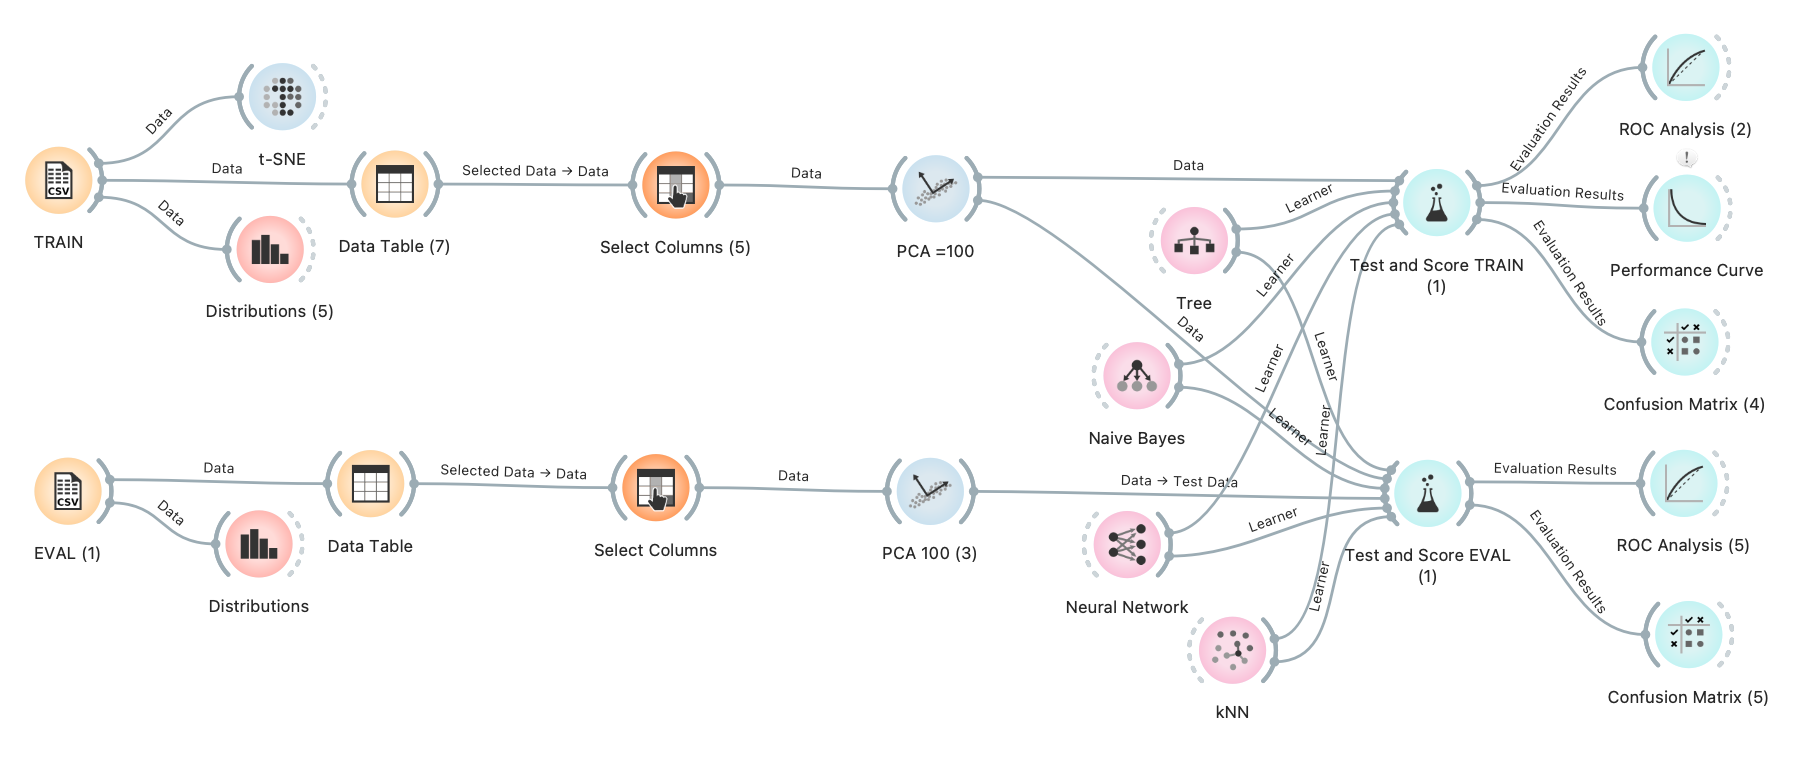

In [33]:
from IPython.display import Image, display # type: ignore
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP3_SLRP_2026/images/Train-Eval.png",width=1000))

#### `II MÉTRIQUES`
`Avec ces métriques en multi-classe, il faut préciser comment on agrège sur les classes` 
 - `par‑classe`, 
 - `macro`,
 - `micro`, 
 - `parfois weighted`.

`L’interprétation reste la probabilité qu’un exemple de la classe k soit scoré plus haut qu’un exemple qui n’est pas dans k puis on moyenne sur les classes`. 

_`2.1 AUC (ROC AUC)`_
- Mesure globale de la capacité du modèle à séparer positifs et négatifs.
- C’est l’aire sous la courbe ROC (TPR en fonction de FPR) pour tous les seuils.
- 0,5 ≈ aléatoire, 1 = parfait; plus c’est proche de 1, mieux le modèle discrimine.
- Il n’y a pas un AUC unique naturel comme en binaire.
- On définit des AUC un‑contre‑tous par classe (courbe ROC de la classe k vs le reste), 
- puis on peut faire une moyenne macro ou weighted des AUC par classe.

_`2.2 CA (accuracy) CA`_ = $\large\frac{TP+TN}{TP+TN+FP+FN}$ 
- C'est le nombre total de prédictions correctes / nombre total d’exemples
- Proportion de prédictions correctes.
- Simple, mais trompeuse si les classes sont très déséquilibrées.
- En multi‑classe, cette mesure peut être très élevée 
- Car les classes majoritaires sont correctement prédites, 
- Même si certaines classes rares sont catastrophiques.

_`2.3 MCC (Matthews Correlation Coefficient) MCC`_ = $\large\frac{TP⋅TN−FP⋅FN}{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}$ 
- Corrélation entre prédictions et vraies étiquettes, de −1 à 1.
- Très robuste sur données déséquilibrées même avec des classes déséquilibrées.
- Une généralisation du MCC s’appuie sur la matrice de confusion multi‑classe:
  - 1 = prédiction parfaite
  -  0 ≈ aléatoire
  - -1 = complètement inversé

__Primo on définit par classe, en traitant chaque classe k comme le « positif » contre toutes les autres__.

_`2.4 Précision (Precision) Prec`_ = $\large \frac{TP_k}{TP_k+FP_k}$ 
- Parmi tout ce que le modèle prédit comme positif, part qui est vraiment positive.
- Sensible aux faux positifs.

_`2.5 Rappel (Recall, Sensitivity) Rec`_ = $\large\frac{TP_k}{TP_k+FN_k}$ 
- Parmi tous les vrais positifs, part que le modèle arrive à trouver.
- Sensible aux faux négatifs.

_`2.6 F1-score F1`_ = 2.$\large\frac{Prec_k⋅Rec_k}{Prec_k+Rec_k}$
- Moyenne harmonique précision / rappel, équilibre les deux.
- Utile lorsque l'on veut un compromis entre faux positifs et négatifs, en classe minoritaire.
 
_`2.7. Macro‑average, moyenne arithmétique sur les classes`_
- Macro‑Prec = moyenne des $Precision_k$
- Macro‑Rec = moyenne des $Recall_k$
- Macro‑F1 = moyenne des $F1_k$, chaque classe compte autant, utile pour voir l'impacte des classes rares.

_`2.8. Micro‑average`_ 
- on somme tous les TP, FP, FN sur toutes les classes, 
- on recalcule une seule precision/recall/F1 à partir de ces totaux.  

_`2.9. Weighted‑average`_
- moyenne des $F1_k$ pondérée par le nombre d’exemples de chaque classe.
- Compromis entre macro (équilibre classes) et micro (équilibre exemples).

__`Avec des classes déséquilibrées on commente typiquement macro‑F1 ou weighted‑F1 et l’Accuracy`.__

### `III. MÉTHODE`
_`3.1. Préparation des données: (ces étapes ont été réalisées dans le cadre de la livraison de SLURP)`_
- Séparer proprement train / dev / test (ou train/test si la dev est déjà fixée dans le corpus).
- Construire les embeddings (BERT/SBERT) pour toutes les phrases, 
- Garder la même normalisation et le même encodage pour tous les splits.
 
_`3.2. Valider les modèles sur le train (Test & Score)`_
- Sur le train uniquement (ou train+dev), avec validation croisée stratifiée :
- Tester les modèles 
    - Tree, 
    - Naïve Bayes, 
    - kNN, 
    - Neural Network, 
- Fixer les hyperparamètres raisonnables.
- Pour chaque modèle, récupérer 
    - CA, 
    - macro‑F1 (ou weighted‑F1), 
    - macro‑AUC, 
    - MCC, en moyenne sur les folds.
- _Option :_ 
    - faire une recherche sur les hyperparamètres (k de kNN, profondeur de l’arbre, taille du MLP) 
    - comparant les scores moyens sur la validation croisée.

_`3.3. Choisir le « meilleur » modèle`_
- Choisir le modèle (et ses hyperparamètres) qui maximise une métrique pertinente, 
- Typiquement macro‑F1 ou MCC, en vérifiant que l’accuracy n’est pas obtenue au détriment des classes rares.
- Utiliser aussi la table de comparaison statistique (comme celle de ta capture) 
- Et vérifier que les différences de CA ou F1 sont significatives et pas négligeables.

_`3.4. Évaluer sur le test`_
- Une fois le modèle choisi, ré‑entraîner ce modèle sur tout le train (ou train+dev).
- L’appliquer sur le test une seule fois, 
- reporter CA, macro‑F1, macro‑AUC, MCC, plus la matrice de confusion pour voir les intentions les plus confondues.

_`3.5. Interpréter`_
- Cohérence entre CV et test (pas de sur‑ajustement massif), 
- Quelles intentions sont bien apprises ou non,
- Comparaison qualitative entre modèles (par ex. NN meilleur AUC et F1 que kNN et Tree).


##### __`1.6.1. k‑NN (k‑Nearest Neighbors)`__
- _Type_ : méthode paresseuse, non paramétrique, classification ou régression.
- _Idée_ : la prédiction d’un point se fait par vote (ou moyenne) des k exemples les plus proches.
- _Forces_ : simple, efficace si la métrique de distance est pertinente, bon avec beaucoup de données.
- _Faiblesses_ : coûteux au prédire, sensible au choix de k et à l’échelle des features.

`1.6.1.1 Choix de la valeur de k avec kNN` 
- Regarder le compromis biais/variance + la performance en validation croisée sur le train
- Méthode pratique on définit une petite grille de valeurs par exemple k  dans 3,5,7,9,11,15.
- Validation croisée avec Test & Score pour chaque k et on regarde macro‑F1, CA, MCC.
- Choisir k petit ayant une performance proche du meilleur score, donnant un modèle réactif peu instable.

| k  | macro‑F1 | CA       | MCC    |
|----|----------|----------|--------|
| 3  | 0.830    | 0.829    | 0.790  |
| 5  | 0.829    | 0.829    | 0.790  |
|`7` | `0.844`  | `0.846`  | `0.808`|
| 9  | 0.855    | 0.855    | 0.820  |
| 11 | 0.851    | 0.855    | 0.820  |
| 15 | 0.843    | 0.848    | 0.811  |

##### __`1.6.2. Decision Tree`__
- _Type_ : modèle supervisé, structure arborescente (if–then).
- _Idée_ : très interprétable, gère bien variables mixtes, peu de prétraitement.     
- _Faiblesses_ : tendance à l’overfitting si non régularisé, frontières de décision en escalier.

`1.6.2.1 Choix des paramètres avec Tree`
- La méthode est identique à celle de kNN 
- Tester la profondeur max ∈ {3, 5, 7, None}, 
- Nombre minimal d’exemples par feuille ∈ {1, 5, 10}.

| deep | leaves | macro‑F1      |  CA           | MCC           |
|:----:|:------:|:-------------:|--------------:|:-------------:|
| 3    | 1...4  | 0.580...0.582 | 0.596...0.597 | 0.485...0.487 |
| 5    | 1...4  | 0.608...0.615 | 0.610...0.612 | 0.505...0.509 |
| 7    | 1...4  | 0.596...0.611 | 0.599...0.615 | 0.492...0.511 |
| 9    | 1...4  | 0.597...0.600 | 0.599...0.603 | 0.494...0.500 |
| 11   | 1...4  | 0.599...0.611 | 0.601...0.615 | 0.497...0.512 |
| 13   | 1...4  | 0.599...0.611 | 0.601...0.611 | 0.497...0.512 |
| 15   | 1...4  | 0.600...0.611 | 0.601...0.615 | 0.497...0.501 |

_`Pour le classifieur Arbre de décision, nous retiendrons`_ 
- Une profondeur maximale à 5. 
- Un nombre minimal d’exemples par feuille à 2–3. 
L’arbre final reste suffisamment expressif pour modéliser les différences entre intentions, tout en conservant une complexité contrôlée et un risque de sur‑apprentissage limité.

`1.6.3. Neural Network (réseau de neurones feed‑forward)`
 - _Type_ : modèle paramétrique, couches de neurones avec fonctions d’activation.
 - _Idée_ : apprend des représentations non linéaires complexes via composition de couches.
 - _Forces_ : très flexible, capable de modéliser des relations hautement non linéaires.
 - _Faiblesses_ : requiert plus de données, tuning des hyperparamètres, moins aisement interprétable.

`1.6.3.1 Evaluation de l'architecture`
| Activation | Régularization | Couche 1 | Couche 2  | Couche 3.   | macro‑F1      |  CA           | MCC          |
|:----------:|:------------:|:--------:|:---------:|:-----------:|:-------------:|:-------------:|:--------------:|
| Relu       | 1e-3....4e-4 | 128      | ...       | ...         | 0.888...0.888 | 0.888...0.888 | 0.859...0.859  |
| Logisitic  | 1e-3....4e-4 | 128      | ...       | ...         | 0.895...0.895 | 0.895...0.895 | 0.868...0.868  |
| Relu       | 1e-3....4e-4 | 128      | 128       | 128         | 0.873...0.876 | 0.874...0.876 | 0.841...0.844  |
| Logisitic  | 1e-3....4e-4 | 128      | 128       | 128         | 0.773...0.773 | 0.800...0.800 | 0.750...0.750  |
| Relu       | 1e-3....4e-4 | 128      | 128,128   | 128,128,128 | 0.882...0.884 | 0.881...0.884 | 0.850...0.853  |

Au vu des résultats du tableau, nous retenons comme modèle MLP final une architecture 384‑128‑7 avec fonction d’activation ReLU dans la couche cachée et une régularisation λ comprise entre 10⁻³ et 4·10⁻⁴. 

Ce choix offre un compromis satisfaisant entre performance (macro‑F1 ≈ 0,89, MCC ≈ 0,86) et simplicité du modèle, tout en évitant les problèmes de saturation observés avec la fonction logistic dans les réseaux plus profonds. 


##### __`1.6.4. Naïve Bayes`__
- _Type_ : classifieur, basé sur le théorème de Bayes (hyp. d’indépendance conditionnelle des features).
- _Idée_ : modélise $P(y)$ et $P(x_i∣y)$, puis choisit la classe avec la probabilité a posteriori max.
- _Forces_ : très rapide, peu de données nécessaires, souvent performant en texte (Multinomial NB).
- _Faiblesses_ : hypothèse d’indépendance souvent fausse, limite la performance maximale possible.

##### __`1.6.5. k‑Means`__
- _Type_ : méthode de clustering non supervisé.
- _Idée_ : partitionne les données en k groupes en minimisant la somme des distances aux centroïdes.
- _Forces_ : simple, rapide, fonctionne bien si les clusters sont à peu près sphériques et bien séparés.
- _Faiblesses_ : fixer k, sensible aux val. initiales et outliers, suppose des clusters de taille et forme « raisonnables ».

| Tâche   | kNN    | Tree.  | MLP    | Naïve Bayes| 
|---------|--------|--------|--------|------------|
| Accuracy| 0.844  | 0.615  | 0.888  |0.823       |
| macro-F1| 0.846  | 0.612  | 0.888  |0.812       |
| MCC.    | 0.808  | 0.505  | 0.859  |0.772       |


#### `1.7. Widget Test & Score des algorithmes d'apprentissage`

##### `1.7.1 Description`

Différents schémas d'échantillonnage sont disponibles, y compris l'utilisation de données de test distinctes. Le widget remplit quatre fonctions : 
 - `premièrement`: Affiche un tableau présentant différentes mesures de performance du classificateur. 
 - `deuxièmement`: Compare l'évaluation des modèles afin d'évaluer la variabilité réelle de ces résultats ; 
 - `troisièmement`: Génère les résultats d'évaluation, pour analyser les performances des classificateurs ; 
 - `quatrièmement`: Génère les prédictions visualisables dans un tableau de données ou analysées ultérieurement.

##### `1.7.2 Évaluation moyenne des modèles`

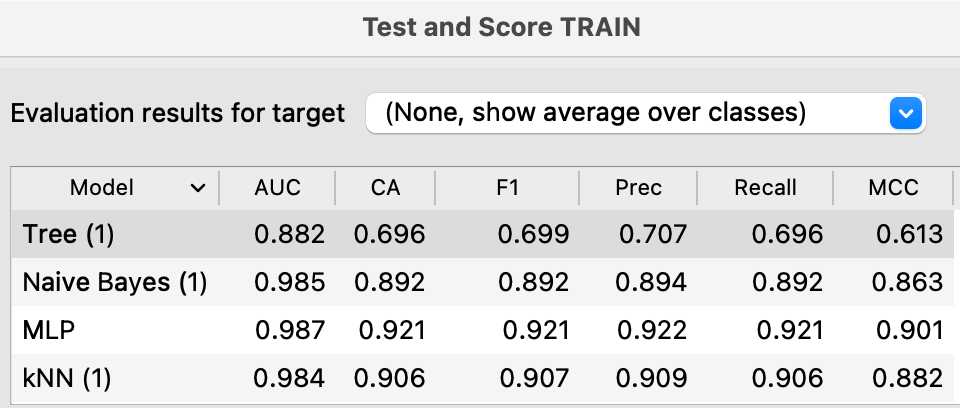

In [50]:
from IPython.display import Image, display # type: ignore
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP3_SLRP_2026/images/TrainModels.png",width=400))

##### `1.7.3 Comparaison des modèles`

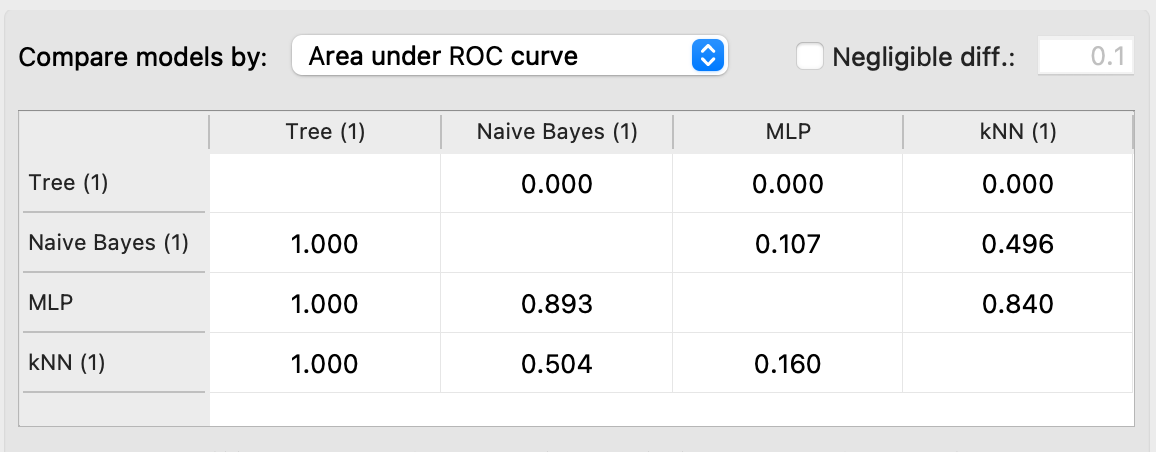

In [49]:
from IPython.display import Image, display # type: ignore
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP3_SLRP_2026/images/compareModels.png",width=500))

`Comment lire une cellule :`
- Les lignes = modèle de référence.
- Les colonnes = modèle avec lequel on compare.

`La valeur de la cellule correspond à :` 
- La performance du modèle de la colonne divisée par la performance du modèle de la ligne, pour la métrique sélectionnée.
- Ré‑échantillonne/arrondit ces ratios sur la base de toutes les répétitions/folds et de la comparaison statistique interne.
- Reflète la proportion de fois où un modèle est meilleur qu’un autre, ici ≈ 0,659.
- __Tree sur les différentes partitions de validation croisée, est 0 fois supérieur__.
- __sur les différentes partitions de validation croisée, MLP bat Naive Bayes dans 84 % des cas__. 

`Nous remarquons que Desicion Tree ne répond pas aux exigences de performances nous l'ignorons`

`La représentation montre que, sur toutes les métriques, les trois modèles kNN, Naive Bayes et MLP se dominent mutuellement de façon nuancée, alors que Tree est systématiquement perdant.`

##### `1.7.3 Évaluation du modèle dominant`

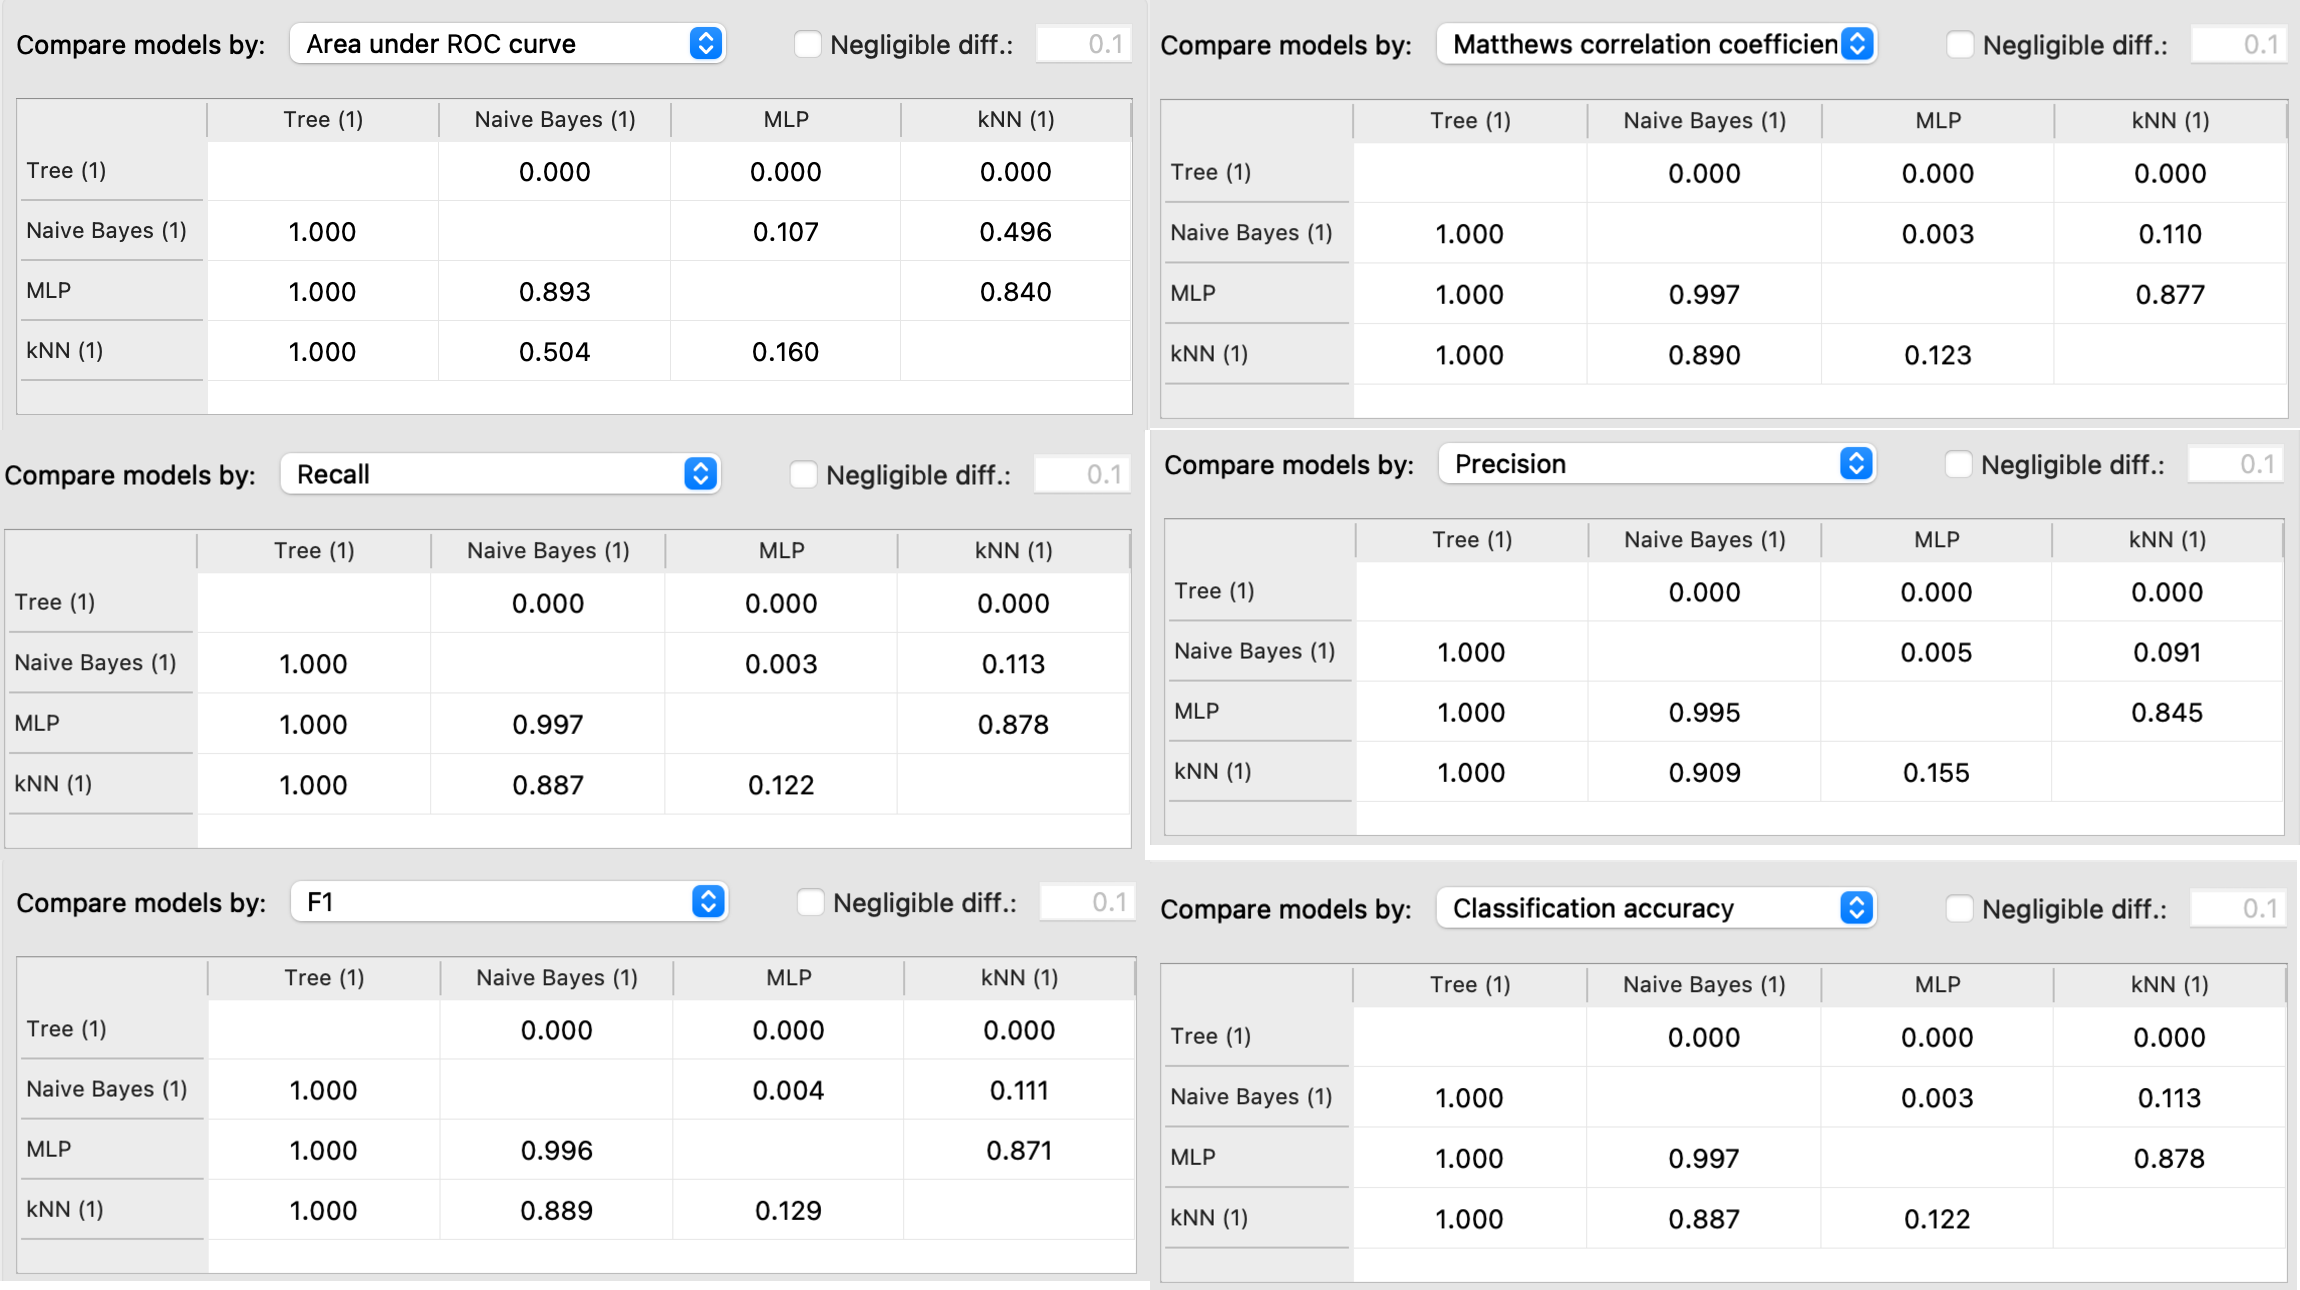

In [56]:
from IPython.display import Image, display # type: ignore
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP3_SLRP_2026/images/ImageToStl.png",width=1000))

<div style="font-size: 11px;">

| Modèle x fois > à | AUC             | CA              | F1              | Précision       | Rappel          | MCC              | 
|-------------------|-----------------|-----------------|-----------------|-----------------|-----------------|------------------|
| kNN               |`0.2 MLP`,0.5 NB |`0.1 MLP`, 0.9 NB |`0.1 MLP`, 0.9 NB |`0.1 MLP`, 0.9 NB |`0.1 MLP`, 0.9 NB |`0.1 MLP`, 0.9 NB  | 
| Naive Bayes       |`0.1 MLP`,0.5 kNN|`0. MLP`, 0.1 kNN|`0.  MLP`, 0.1 kNN|`0.  MLP`, 0.1 kNN|`0.  MLP`, 0.1 kNN|`0.  MLP`, 0.1 kNN | 
| MLP               |`0.8 KNN`,0.9 NB | 1   NB,  `0.9 kNN`|1.  NB,  `0.9 kNN`|`0.8 kNN`, 1.  NB | 1.  NB,  `0.9 kNN`|`0.8 kNN`, 0.1 MLP |
| Tree              | 0.     , 0.     | 0.    ,  0.     | 0.    ,  0.     | 0.     , 0.     | 0.    ,  0.     | 0.     , 0.      | 
</div>

##### `1.7.4 Modèle MLP modèle domine`

__`Au vu du tableau de comparaison des modèles`__ 
Le `MLP` apparaît nettement comme le modèle le plus performant. Il domine la plupart des autres algorithmes sur les métriques notamment 
   - AUC, 
   - F1, 
   - précision, 
   - rappel
   - MCC, 
Ceci indique une meilleure capacité de discrimination et un bon équilibre entre faux positifs et faux négatifs. Les modèles kNN et Naive Bayes restent surtout intéressants comme baselines, tandis que l’arbre de décision montre des performances globalement insuffisantes.

#### `1.7.5 Matrices de confusion normalisées, sur le TRAIN`

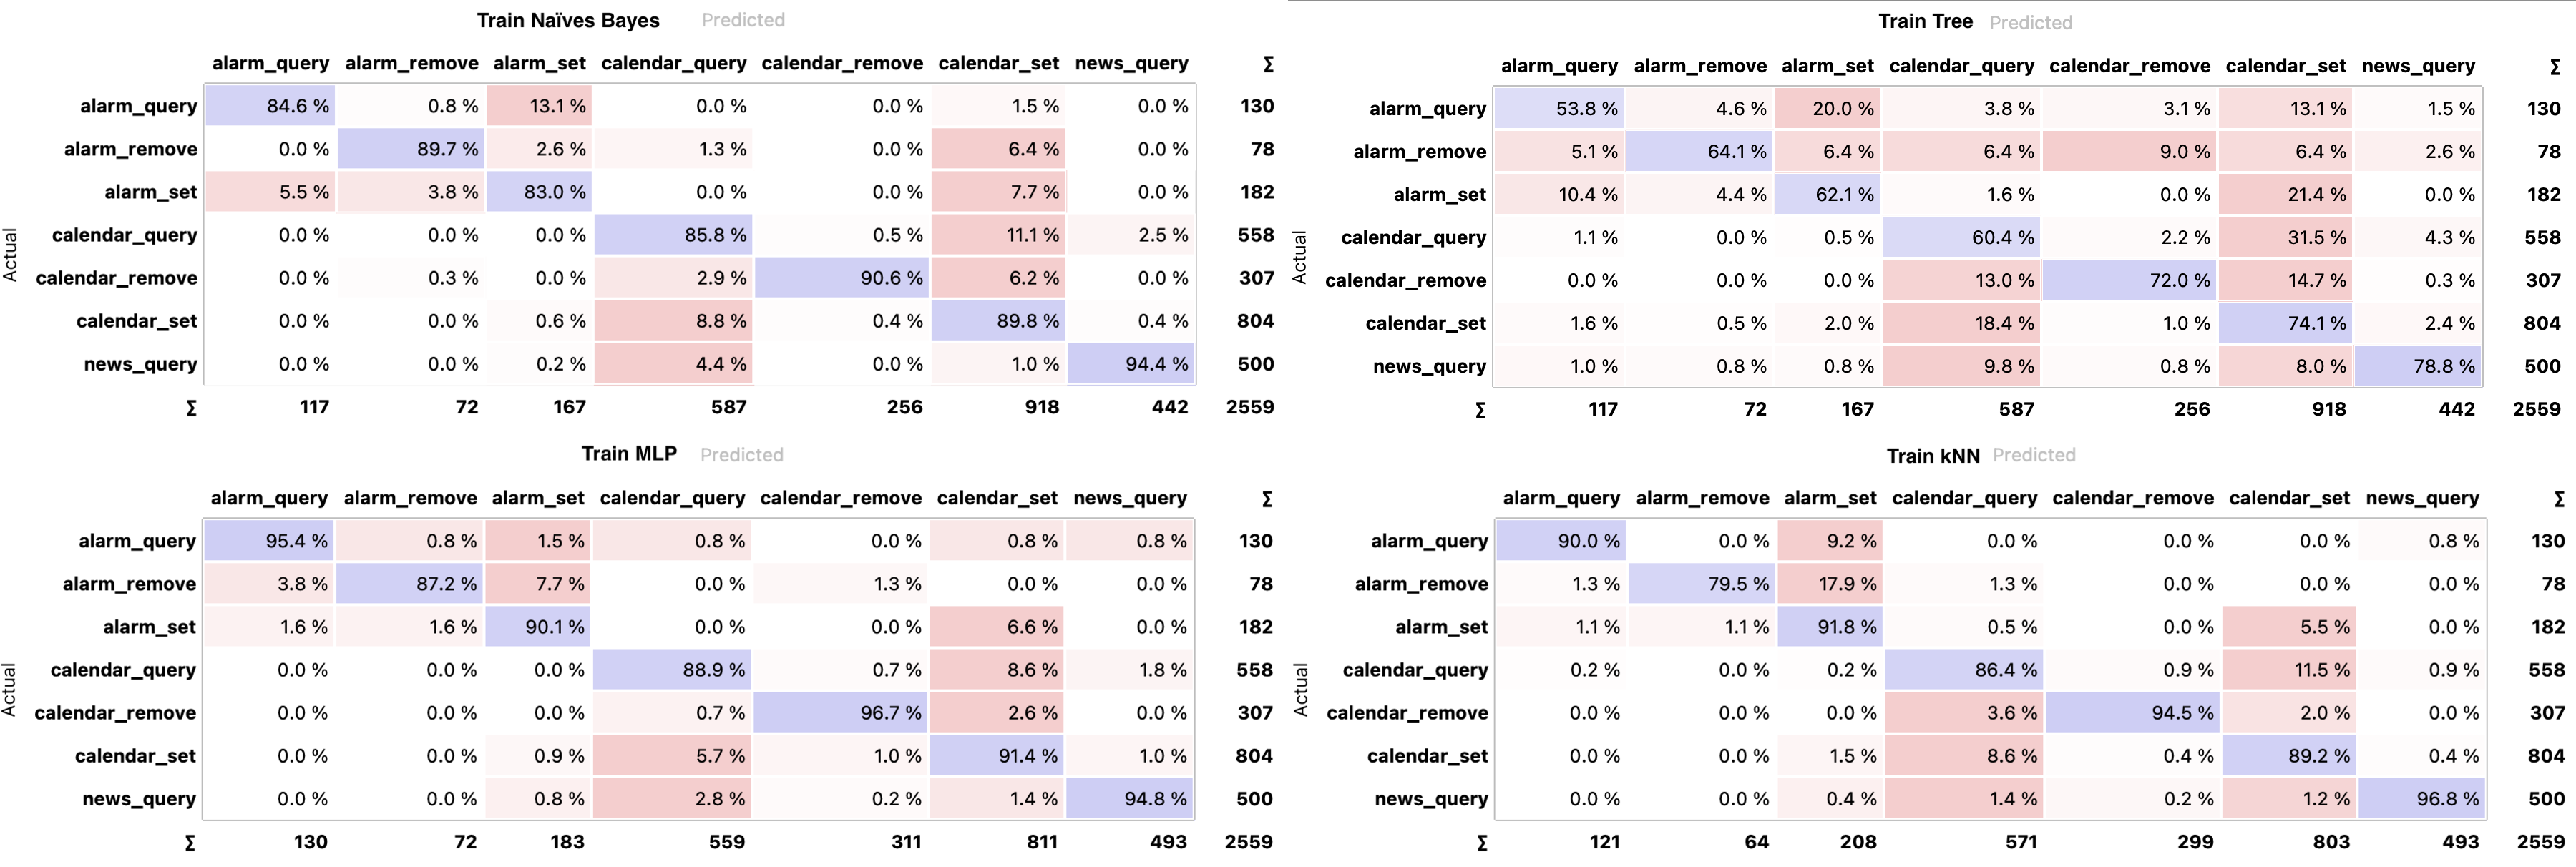

In [66]:
from IPython.display import Image, display # type: ignore
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP3_SLRP_2026/images/trainmatrix.png",width=1200))

- `Naïve Bayes`avec des résultats corrects et des erreurs pour les classes liées à calendrier et de confusion entre calendar_query, calendar_set
- ​`Décision (Tree)`est moins bon les pourcentages sur la diagonale sont faibles, les classes mal classées, les performances globales faibles.
- `MLP est dominant(> 90 %)` avec peu de confusion entre les requêtes c’est le modèle qui apprend le mieux la structure des données.
- `kNN`avec des diagonales fortes, laisse plus de confusion que MLP, ce qui confirme que le MLP reste légèrement supérieur.

Les matrices de confusion normalisées sur le jeu d’apprentissage pour les modèles (Naïve Bayes, arbre de décision, kNN et MLP). On constate que MLP (et dans une moindre mesure le kNN) affiche des diagonales très marquées, traduisant une excellente reconnaissance des différentes classes de requêtes, alors que Naïve Bayes et surtout l’arbre de décision commettent davantage d’erreurs, en particulier sur les classes liées au calendrier. Ces résultats confirment que le MLP est le modèle le plus fiable sur le jeu TRAIN.

##### `1.8 Workflow complet Train / Eval / Test`

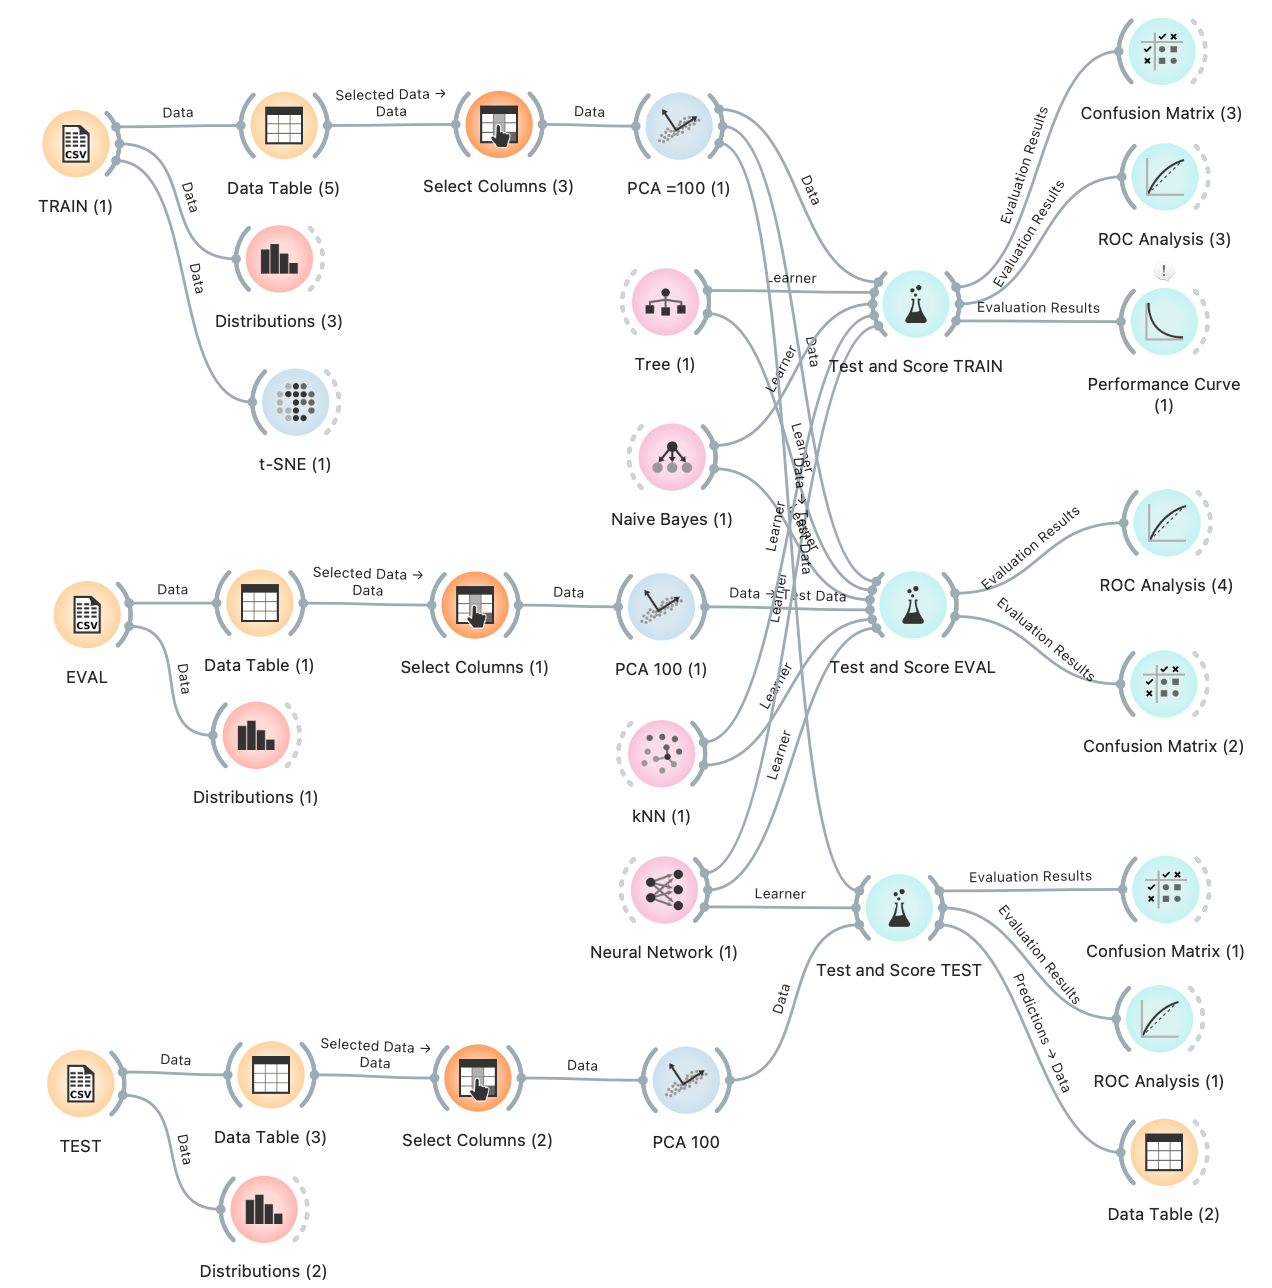

In [ ]:
from IPython.display import Image, display # type: ignore
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP3_SLRP_2026/images/archTrainEvalTest.png",width=600))

##### `1.8 Description du Workflow`

`La figure ci‑dessus présente le workflow Orange utilisé pour l’évaluation des modèles.` 

 - Les données sont séparées en trois ensembles TRAIN, EVAL et TEST, qui suivent tous le même pré‑traitement (visualisation, sélection de variables, réduction de dimension par PCA) avant d’être envoyés vers les différents apprenants (arbre de décision, Naive Bayes, kNN et réseau de neurones). 

 - L’ensemble TRAIN sert à apprendre les modèles et à obtenir une première estimation des performances via le widget « Test and Score TRAIN ». 

 - L’ensemble EVAL, distinct de TRAIN, est utilisé dans « Test and Score EVAL » pour comparer plus objectivement les modèles et sélectionner le plus performant, à l’aide de matrices de confusion, courbes ROC et courbes de performance. 

 - Enfin, l’ensemble TEST est réservé à l’évaluation finale dans « Test and Score TEST », fournissant une estimation honnête de la capacité de généralisation du modèle retenu.

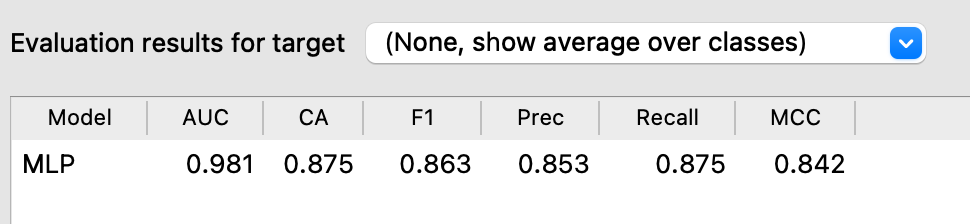

In [67]:
from IPython.display import Image, display # type: ignore
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP3_SLRP_2026/images/testontestdata.png",width=400))